# Explore and understand data

### Imports

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

### Read data

In [ ]:
production = pd.read_csv("../data/bronze/wells_production.csv")
wells = pd.read_csv("../data/bronze/listed_wells.csv")

## 1. Production Dataset

### Dataset structure

In [5]:
production.shape

(405996, 40)

In [29]:
production.columns.tolist()

['idempresa',
 'anio',
 'mes',
 'idpozo',
 'prod_pet',
 'prod_gas',
 'prod_agua',
 'iny_agua',
 'iny_gas',
 'iny_co2',
 'iny_otro',
 'tef',
 'vida_util',
 'tipoextraccion',
 'tipoestado',
 'tipopozo',
 'observaciones',
 'fechaingreso',
 'rectificado',
 'habilitado',
 'idusuario',
 'empresa',
 'sigla',
 'formprod',
 'profundidad',
 'formacion',
 'idareapermisoconcesion',
 'areapermisoconcesion',
 'idareayacimiento',
 'areayacimiento',
 'cuenca',
 'provincia',
 'coordenadax',
 'coordenaday',
 'tipo_de_recurso',
 'proyecto',
 'clasificacion',
 'subclasificacion',
 'sub_tipo_recurso',
 'fecha_data']

In [31]:
production.dtypes

idempresa                     str
anio                        int64
mes                         int64
idpozo                      int64
prod_pet                  float64
prod_gas                  float64
prod_agua                 float64
iny_agua                  float64
iny_gas                   float64
iny_co2                   float64
iny_otro                  float64
tef                       float64
vida_util                 float64
tipoextraccion                str
tipoestado                    str
tipopozo                      str
observaciones                 str
fechaingreso                  str
rectificado                   str
habilitado                    str
idusuario                   int64
empresa                       str
sigla                         str
formprod                      str
profundidad               float64
formacion                     str
idareapermisoconcesion        str
areapermisoconcesion          str
idareayacimiento              str
areayacimiento

The production dataset contains 405,996 records and 40 attributes describing monthly oil, gas and water production, injection activities, operational characteristics and geographical information for Argentine wells.

### Missing values

In [36]:
missing = ( production.isna().sum().sort_values( ascending=False ) )
missing.head( 10 )

vida_util           397379
observaciones       382947
subclasificacion       910
clasificacion          910
tipoextraccion         605
tipopozo               605
tipoestado             605
sub_tipo_recurso       440
idempresa                0
formacion                0
dtype: int64

In [38]:
( missing / len( production ) * 100 ).round( 2 ).head( 10 )

vida_util           97.88
observaciones       94.32
subclasificacion     0.22
clasificacion        0.22
tipoextraccion       0.15
tipopozo             0.15
tipoestado           0.15
sub_tipo_recurso     0.11
idempresa            0.00
formacion            0.00
dtype: float64

### Cardinality 

In [40]:
production["idpozo"].nunique()

4929

In [41]:
production["empresa"].nunique()

55

In [42]:
production["provincia"].nunique()

6

In [43]:
production["cuenca"].nunique()

4

In [44]:
production["areayacimiento"].nunique()

155

### Grain

In [45]:
production[["idpozo", "anio", "mes"]].duplicated().sum()

np.int64(0)

-> One record per well per month.

In [47]:
production.groupby( "idpozo" ).size().describe()

count    4929.000000
mean       82.368837
std        57.386091
min         1.000000
25%        31.000000
50%        80.000000
75%       125.000000
max       244.000000
dtype: float64

### Temporal distribution

In [50]:
production["anio"].min()

np.int64(2006)

In [49]:
production["anio"].max()

np.int64(2026)

In [51]:
production[["anio", "mes"]].drop_duplicates().shape

(244, 2)

In [52]:
production.groupby("anio").size()

anio
2006     2368
2007     2442
2008     2280
2009     1698
2010     2038
2011     2599
2012     3640
2013     5184
2014     8777
2015    12841
2016    17225
2017    20734
2018    24895
2019    28917
2020    31716
2021    34506
2022    38918
2023    43219
2024    48439
2025    54224
2026    19336
dtype: int64

<Axes: xlabel='anio'>

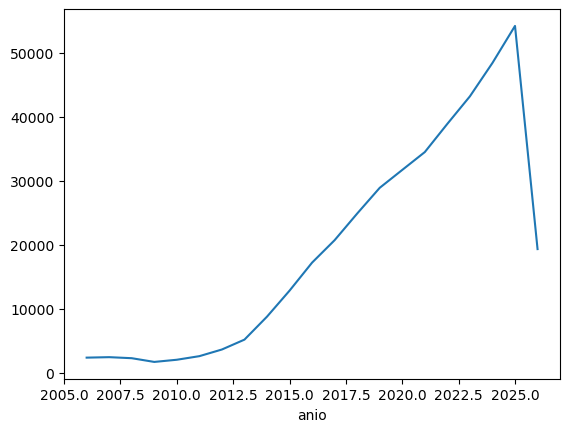

In [57]:
production.groupby("anio").size().plot()

### Companies

In [58]:
production["empresa"].nunique()

55

In [59]:
production["empresa"].value_counts().head(20)

empresa
YPF S.A.                                        221496
CAPEX S.A.                                       20705
PLUSPETROL S.A.                                  20378
PAN AMERICAN ENERGY SL                           19109
TOTAL AUSTRAL S.A.                               15245
COMPAÑÍA GENERAL DE COMBUSTIBLES S.A.            15232
TECPETROL S.A.                                   14821
PAMPA ENERGIA S.A.                               12743
SHELL ARGENTINA S.A.                              8505
YSUR ENERGÍA ARGENTINA S.R.L.                     7721
VISTA ENERGY ARGENTINA SAU                        7338
PETROBRAS ARGENTINA S.A.                          6595
APACHE ENERGIA ARGENTINA S.R.L.                   6448
PAN AMERICAN ENERGY (SUCURSAL ARGENTINA) LLC      4827
OILSTONE ENERGIA S.A.                             4204
QUINTANA E&P ARGENTINA S.R.L.                     2957
EXXONMOBIL EXPLORATION ARGENTINA S.R.L.           2578
CHEVRON ARGENTINA S.R.L.                          1948
PE

In [60]:
production.groupby("idpozo")["empresa"].nunique().value_counts()

empresa
1    3927
2     646
3     194
4     139
5      21
6       2
Name: count, dtype: int64

### Wells

In [61]:
production["idpozo"].nunique()

4929

In [62]:
production.groupby("idpozo").size().describe()

count    4929.000000
mean       82.368837
std        57.386091
min         1.000000
25%        31.000000
50%        80.000000
75%       125.000000
max       244.000000
dtype: float64

In [63]:
production["tipopozo"].value_counts()

tipopozo
Gasífero             221257
Petrolífero          156071
Otro tipo             27320
Sumidero                644
Inyección de Agua        56
Inyección de Gas         43
Name: count, dtype: int64

### Geography

In [64]:
production["provincia"].value_counts()

provincia
Neuquén       357889
Rio Negro      28713
Santa Cruz     15899
Mendoza         3057
Chubut           253
Salta            185
Name: count, dtype: int64

In [65]:
production["cuenca"].value_counts()

cuenca
NEUQUINA           389659
AUSTRAL             15570
GOLFO SAN JORGE       582
NOROESTE              185
Name: count, dtype: int64

In [66]:
production.groupby("idpozo")["provincia"].nunique().value_counts()

provincia
1    4929
Name: count, dtype: int64

In [67]:
production.groupby("idpozo")["cuenca"].nunique().value_counts()

cuenca
1    4929
Name: count, dtype: int64

In [68]:
production.groupby("idpozo")["areayacimiento"].nunique().value_counts()

areayacimiento
1    4929
Name: count, dtype: int64

## 2. Wells Dataset

### Dataset structure

In [28]:
wells.shape

(84242, 51)

In [30]:
wells.columns.tolist()

['idpozo',
 'sigla',
 'formprod',
 'idempresa',
 'idareapermisoconcesion',
 'idareayacimiento',
 'idcuenca',
 'idprovincia',
 'codigopropio',
 'nombrepropio',
 'coordenadax',
 'coordenaday',
 'cota',
 'profundidad',
 'pet_inicial',
 'gas_inicial',
 'agua_inicial',
 'iny_agua_inicial',
 'iny_gas_inicial',
 'iny_otros_inicial',
 'iny_co2_inicial',
 'vida_util_inicial',
 'adjiv_fecha_inicio',
 'adjiv_equipo_utilizar',
 'adjiv_capacidad_perf',
 'adjiv_tipo_reservorio',
 'adjiv_subtipo_reservorio',
 'adjiv_fecha_fin',
 'adjiv_fecha_inicio_term',
 'adjiv_fecha_fin_term',
 'adjiv_fecha_abandono',
 'adjiv_clasificacion',
 'adjiv_subclasificacion',
 'fechadeingreso',
 'adjiv_comp_perf',
 'unique_sigla_formprod',
 'areapermisoconcesion',
 'areayacimiento',
 'cuenca',
 'provincia',
 'petroleo',
 'gas',
 'agua',
 'periodo',
 'clasificacion',
 'subclasificacion',
 'tipo_reservorio',
 'subtipo_reservorio',
 'comp_perf',
 'gasplus',
 'fecha_data']

In [32]:
wells.dtypes

idpozo                        int64
sigla                           str
formprod                        str
idempresa                       str
idareapermisoconcesion          str
idareayacimiento                str
idcuenca                        str
idprovincia                     str
codigopropio                    str
nombrepropio                    str
coordenadax                 float64
coordenaday                 float64
cota                        float64
profundidad                 float64
pet_inicial                 float64
gas_inicial                 float64
agua_inicial                float64
iny_agua_inicial            float64
iny_gas_inicial             float64
iny_otros_inicial           float64
iny_co2_inicial             float64
vida_util_inicial           float64
adjiv_fecha_inicio              str
adjiv_equipo_utilizar           str
adjiv_capacidad_perf        float64
adjiv_tipo_reservorio       float64
adjiv_subtipo_reservorio    float64
adjiv_fecha_fin             

### Missing values

In [70]:
missing_w = ( wells.isna().sum().sort_values( ascending=False ) )
missing_w.head( 25 )

adjiv_fecha_abandono        80101
subtipo_reservorio          79612
adjiv_subtipo_reservorio    79525
fecha_data                  68750
fechadeingreso              68750
adjiv_fecha_inicio_term     35870
adjiv_fecha_fin_term        35869
adjiv_capacidad_perf        33911
comp_perf                   33629
adjiv_comp_perf             33629
adjiv_fecha_fin             33621
adjiv_equipo_utilizar       33516
adjiv_fecha_inicio          33478
tipo_reservorio             21518
adjiv_tipo_reservorio       21518
subclasificacion            17939
clasificacion               17939
adjiv_subclasificacion      17937
adjiv_clasificacion         17924
codigopropio                 7997
nombrepropio                 4550
formprod                     2680
unique_sigla_formprod         152
cuenca                          3
gas_inicial                     0
dtype: int64

In [71]:
( missing_w / len( wells ) * 100 ).round( 2 ).head( 25 )

adjiv_fecha_abandono        95.08
subtipo_reservorio          94.50
adjiv_subtipo_reservorio    94.40
fecha_data                  81.61
fechadeingreso              81.61
adjiv_fecha_inicio_term     42.58
adjiv_fecha_fin_term        42.58
adjiv_capacidad_perf        40.25
comp_perf                   39.92
adjiv_comp_perf             39.92
adjiv_fecha_fin             39.91
adjiv_equipo_utilizar       39.79
adjiv_fecha_inicio          39.74
tipo_reservorio             25.54
adjiv_tipo_reservorio       25.54
subclasificacion            21.29
clasificacion               21.29
adjiv_subclasificacion      21.29
adjiv_clasificacion         21.28
codigopropio                 9.49
nombrepropio                 5.40
formprod                     3.18
unique_sigla_formprod        0.18
cuenca                       0.00
gas_inicial                  0.00
dtype: float64

### Cardinality

In [72]:
wells["idpozo"].nunique()

84242

In [73]:
wells["sigla"].nunique()

77061

In [74]:
wells["formprod"].nunique()

79

In [75]:
wells["provincia"].nunique()

11

In [76]:
wells["cuenca"].nunique()

9

In [77]:
wells["areayacimiento"].nunique()

1082

### Well uniqueness

In [78]:
wells["idpozo"].duplicated().sum()

np.int64(0)

Checked uniqueness of id just in case, one record per well

### Depth

In [79]:
wells["profundidad"].describe()

count     84242.000000
mean       1698.195063
std        1736.239076
min           0.000000
25%        1028.000000
50%        1583.000000
75%        2345.000000
max      378939.000000
Name: profundidad, dtype: float64

<Axes: >

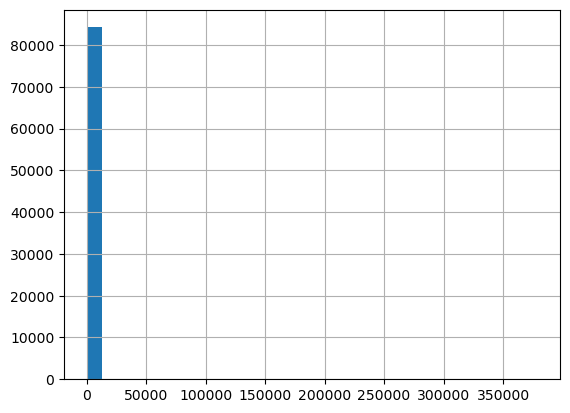

In [80]:
wells["profundidad"].hist(bins=30)

### Reservoir

In [83]:
wells["tipo_reservorio"].value_counts()

tipo_reservorio
CONVENCIONAL       57690
NO CONVENCIONAL     4633
SIN RESERVORIO       396
NO DISCRIMINADO        5
Name: count, dtype: int64

In [84]:
wells["subtipo_reservorio"].value_counts()

subtipo_reservorio
SHALE    3014
TIGHT    1616
Name: count, dtype: int64

In [85]:
wells["formprod"].value_counts().head(20)

formprod
BBAR    9197
CORI    8566
CSEC    8489
GCHU    8021
MELC    4149
QTUC    4019
AGRI    3948
VMUT    3183
FIMP    2724
HUIT    2631
LOTE    2116
SPRI    2071
CENT    2003
LAJA    1836
SBLA    1795
RAYO    1736
TORD    1690
BARR    1191
MULI    1020
SALA     984
Name: count, dtype: int64

### Location

In [86]:
wells["provincia"].value_counts()

provincia
Santa Cruz          23580
Chubut              22298
Neuquén             18950
Mendoza              8744
Rio Negro            5646
La Pampa             2710
Tierra del Fuego     1242
Salta                 896
Estado Nacional        65
Formosa                65
Jujuy                  46
Name: count, dtype: int64

In [87]:
wells["cuenca"].value_counts()

cuenca
GOLFO SAN JORGE    44045
NEUQUINA           32366
CUYANA              3684
AUSTRAL             3133
NOROESTE             996
NORESTE               11
ÑIRIHUAU               2
ARGENTINA NORTE        1
CAÑADON ASFALTO        1
Name: count, dtype: int64

In [88]:
wells["areayacimiento"].value_counts().head(20)

areayacimiento
PUESTO HERNANDEZ                         2568
MANANTIALES BEHR                         2512
LOS PERALES                              2311
CAMPAMENTO CENTRAL - BELLA VISTA ESTE    2233
DIADEMA                                  2118
EL HUEMUL                                1962
CAÑADON LEON                             1721
CAÑADON SECO                             1648
EL TORDILLO                              1620
EL TRAPIAL                               1359
KM. 20                                   1351
MESETA ESPINOSA                          1228
CAÑADON DE LA ESCONDIDA                  1192
LAS HERAS                                1157
EL CORDON                                1152
25 DE MAYO - MEDANITO SUDESTE LP         1129
PICO TRUNCADO                            1031
CENTENARIO CENTRO                        1009
EL TREBOL                                 993
CHIHUIDO DE LA SIERRA NEGRA               987
Name: count, dtype: int64

In [89]:
wells.groupby("idpozo")["provincia"].nunique().value_counts()

provincia
1    84242
Name: count, dtype: int64

In [90]:
wells.groupby("idpozo")["cuenca"].nunique().value_counts()

cuenca
1    84239
0        3
Name: count, dtype: int64

In [91]:
wells.groupby("idpozo")["areayacimiento"].nunique().value_counts()

areayacimiento
1    84242
Name: count, dtype: int64

### Classification

In [92]:
wells["clasificacion"].value_counts()

clasificacion
EXPLOTACION       56851
EXPLORACION        5432
SERVICIO           3987
ALMACENAMIENTO       33
Name: count, dtype: int64

In [93]:
wells["subclasificacion"].value_counts()

subclasificacion
DESARROLLO               50767
AVANZADA                  6277
EXPLORACION               3844
INYECTOR DE AGUA          3688
EXTENSION                  848
EXPLORATORIO PROFUNDO      322
INYECTOR TERCIARIA         181
ESTUDIO                    107
CONTROL                     97
SUMIDERO                    61
PRODUCTOR DE AGUA           48
ALMACENAMIENTO DE GAS       29
EXPLORATORIO SOMERO         18
INYECTOR DE GAS              9
INYECTOR DE VAPOR            7
Name: count, dtype: int64

In [94]:
wells["comp_perf"].value_counts()

comp_perf
SIN DATO                            12328
YPF                                  7658
Pride International                  6096
San Antonio Internacional            5370
DLS Argentina                        4928
Petreven                             2656
Nabors International Argentina       1386
Venver                               1355
Almea Austral                        1315
Helmerich & Payne                    1266
Perez Companc (CNPC)                 1193
Quitral Co.                           767
Quintana Well Pro                     669
Oil Drilling & Exploration (ODE)      569
Rio Colorado                          535
Ensign Argentina                      480
Key Energy Services                   384
Kenting Drilling                      376
Estrella                              292
Servicios Welltech                    280
Saipem Argentina                      233
Drillers International                227
SP Argentina                          142
Dresser Atlas           

## 3. Relationship Analysis

In [ ]:
production_wells = set( production["idpozo"] )
master_wells = set( wells["idpozo"] )

print( "Production wells:", len( production_wells ) )
print( "Master wells:", len( master_wells ) )
print( "Intersection:", len( production_wells & master_wells ) )

Production wells: 4929
Master wells: 84242
Intersection: 4633


In [ ]:
missing_in_wells = production_wells - master_wells
len( missing_in_wells )

296

-> Productive wells missing in dataset wells

In [102]:
missing_in_production = master_wells - production_wells
len( missing_in_production )

79609

### Consistency

In [104]:
merged = production.merge( wells, on="idpozo", suffixes=("_prod", "_well") )

In [105]:
( merged["provincia_prod"] == merged["provincia_well"] ).mean()

np.float64(1.0)

In [106]:
( merged["cuenca_prod"] == merged["cuenca_well"] ).mean()

np.float64(1.0)

In [108]:
( merged["areayacimiento_prod"] == merged["areayacimiento_well"] ).mean()

np.float64(0.9978923459924819)

In [116]:
merged[merged["areayacimiento_prod"]!= merged["areayacimiento_well"]][["idpozo","areayacimiento_prod","areayacimiento_well"]]

,idpozo,areayacimiento_prod,areayacimiento_well
303948,73804,EL CERRITO,EL CERRITO
303980,135216,EL CERRITO,EL CERRITO
304161,135216,EL CERRITO,EL CERRITO
304167,73804,EL CERRITO,EL CERRITO
304211,73804,EL CERRITO,EL CERRITO
...,...,...,...
374593,158001,EL CERRITO,EL CERRITO
374595,158021,EL CERRITO,EL CERRITO
374597,158020,EL CERRITO,EL CERRITO
374607,135216,EL CERRITO,EL CERRITO


In [ ]:
missing_df = production[production["idpozo"].isin( missing_in_wells )]
missing_df[["idpozo","empresa","provincia","cuenca"]].drop_duplicates().head( 20 )

,idpozo,empresa,provincia,cuenca
20,145330,YSUR ENERGÍA ARGENTINA S.R.L.,Neuquén,NEUQUINA
66,145329,YSUR ENERGÍA ARGENTINA S.R.L.,Neuquén,NEUQUINA
8463,137007,YPF S.A.,Neuquén,NEUQUINA
10374,153313,YPF S.A.,Neuquén,NEUQUINA
10392,146207,YPF S.A.,Neuquén,NEUQUINA
23574,166873,YPF S.A.,Neuquén,NEUQUINA
23576,166874,YPF S.A.,Neuquén,NEUQUINA
23578,166875,YPF S.A.,Neuquén,NEUQUINA
23580,166876,YPF S.A.,Neuquén,NEUQUINA
23582,166877,YPF S.A.,Neuquén,NEUQUINA


In [111]:
missing_df["anio"].describe()

count    2704.000000
mean     2020.645710
std         4.958525
min      2008.000000
25%      2016.000000
50%      2021.000000
75%      2026.000000
max      2026.000000
Name: anio, dtype: float64

In [112]:
missing_df["anio"].value_counts().sort_index()

anio
2008      6
2009     11
2010     17
2011     48
2012     60
2013     92
2014    142
2015    155
2016    167
2017    173
2018    142
2019    126
2020    132
2021    132
2022    124
2023    102
2024      8
2025    231
2026    836
Name: count, dtype: int64

In [ ]:
( merged["areayacimiento_prod"].str.strip() != merged["areayacimiento_well"].str.strip() ).sum()

np.int64(0)

## Conclusions

### Production Dataset

The production dataset contains 405,996 records and 4,929 unique wells, covering the period from 2006 to 2026. The dataset follows a clear grain of one record per well per month, as no duplicates were found for the combination (idpozo, anio, mes). The data is heavily concentrated in Neuquina and the province of Neuquén. The dataset includes production and injection measures such as oil, gas, water, and CO₂ injection, making it a suitable candidate for the future fact table. Most wells appear repeatedly over time, with an average of 80 monthly observations per well, confirming the temporal nature of the dataset.


### Wells Dataset

The wells dataset contains 84,242 unique wells, with exactly one record per well, making it a natural source for a dimension table. Several attributes are available; including location, reservoir type, classification, depth, and operational information. Some columns contain a very high percentage of missing values (above 80–90%), suggesting that they should be carefully evaluated before being included in downstream layers. The dataset covers a broader universe of wells than the production dataset and includes wells from multiple places across Argentina.

### Relationship between datasets

The datasets can be integrated using idpozo as the business key. The relationship between the datasets is a one-to-many relationship, where a single well can be associated with multiple monthly production records. Out of the 4,929 wells present in the production dataset; 4,633 wells were found in the wells dataset, while 296 wells were not found in the wells catalog. These unmatched wells appear to be valid production records rather than data quality errors, as they belong primarily to major operators such as YPF and YSUR and are concentrated in Neuquina. A large proportion of these records are associated with recent years (2025–2026), suggesting possible synchronization or update differences between the source systems.


Regarding data consistency, for wells that exist in both datasets consistency checks showed excellent agreement. 
Attribute	Consistency
Province	100%
Basin (Cuenca)	100%
Field (Área Yacimiento)	100% after string normalization

The initial discrepancies found in the areayacimiento attribute were caused by trailing spaces and formatting differences rather than actual conflicts in the data. These results validate idpozo as the integration key and indicate that both datasets represent the same business entities consistently.


Based on the analysis, the following dimensional model is proposed:
fact_production
    Grain: one record per well per month
dim_well
    Grain: one record per well
dim_date
    Grain: one record per calendar date

The production dataset should become the fact table because it contains the business measures and temporal observations. The wells dataset should become the well dimension because it provides a single record per well with descriptive attributes. Since 296 production wells do not exist in the wells dataset, the integration process should use a LEFT JOIN from production to wells to avoid losing valid production records. For slowly changing dimensions, SCD Type 1 is the preferred approach because the source datasets do not provide historical tracking of attribute changes and the available well attributes are largely descriptive and static. The analysis supports a star schema centered on fact_production, with dim_well and dim_date as the core dimensions.